<a href="https://colab.research.google.com/github/Jolieyolie/AI-agent/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers

In [2]:
import transformers

In [3]:
!pip install transformers[sentencepiece]

In [4]:
!python --version

Python 3.12.13


In [5]:
!mkdir ~/transformers-course
!cd ~/transformers-course

In [5]:
!pip install --upgrade pip setuptools
!rm -rf ~/transformers-course/.env
!python -m venv --without-pip ~/transformers-course/.env
!wget https://bootstrap.pypa.io/get-pip.py -O ~/transformers-course/.env/get-pip.py
!~/transformers-course/.env/bin/python ~/transformers-course/.env/get-pip.py
!rm ~/transformers-course/.env/get-pip.py
!~/transformers-course/.env/bin/pip install --upgrade pip setuptools wheel

--2026-05-11 14:54:48--  https://bootstrap.pypa.io/get-pip.py
Resolving bootstrap.pypa.io (bootstrap.pypa.io)... 151.101.0.175, 151.101.64.175, 151.101.128.175, ...
Connecting to bootstrap.pypa.io (bootstrap.pypa.io)|151.101.0.175|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2226394 (2.1M) [text/x-python]
Saving to: ‘/root/transformers-course/.env/get-pip.py’

/root/transformers- 100%[===================>]   2.12M  --.-KB/s    in 0.06s   

2026-05-11 14:54:48 (33.8 MB/s) - ‘/root/transformers-course/.env/get-pip.py’ saved [2226394/2226394]

  Using cached pip-26.1.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [wheel]


In [6]:
pip install "transformers[sentencepiece]"

In [7]:
ls -a

./  ../  .config/  sample_data/


In [8]:
!source ~/transformers-course/.env/bin/activate

In [10]:
!which python

/usr/local/bin/python


In [9]:
#import required libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# set visual style for plots
sns.set(style="whitegrid")

In [10]:
import warnings
warnings.filterwarnings("ignore")
#tell python to pass warning, so they don't clutter

In [17]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os # Import os module to join paths

# Download latest version
dataset_dir = kagglehub.dataset_download("grouplens/movielens-20m-dataset")

# The 'dataset_dir' variable points to a directory, not a specific file.
# We need to specify the file we want to load, for example, 'rating.csv'.
# The kagglehub.load_dataset function likely expects the relative path to the file within the dataset, not the full system path.
file_to_load = "rating.csv"

print("Path to dataset directory:", dataset_dir)
print("Name of specific file being loaded:", file_to_load)

# Load the specified file using the Pandas adapter
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "grouplens/movielens-20m-dataset",
  file_to_load,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'movielens-20m-dataset' dataset.
Path to dataset directory: /kaggle/input/movielens-20m-dataset
Name of specific file being loaded: rating.csv
Using Colab cache for faster access to the 'movielens-20m-dataset' dataset.
First 5 records:    userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40


In [16]:
!ls {dataset_dir}

genome_scores.csv  genome_tags.csv  link.csv  movie.csv  rating.csv  tag.csv


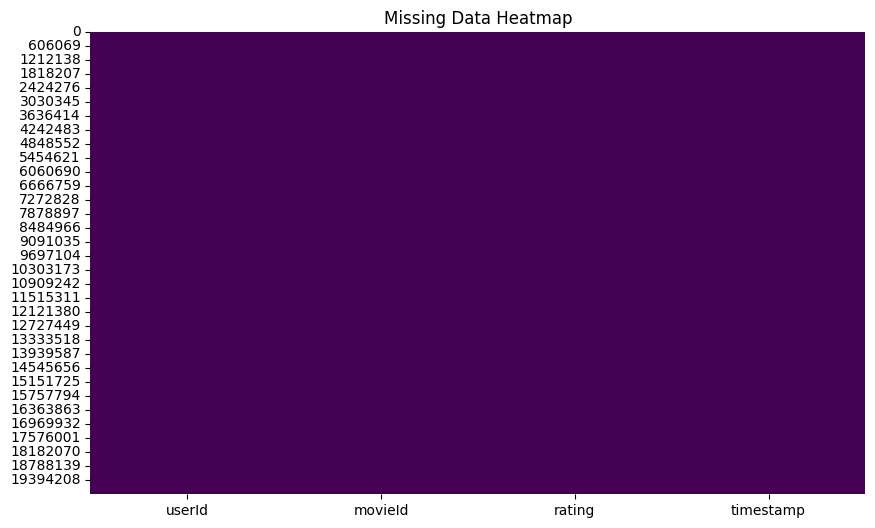

In [19]:
# step 4 visualizing missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

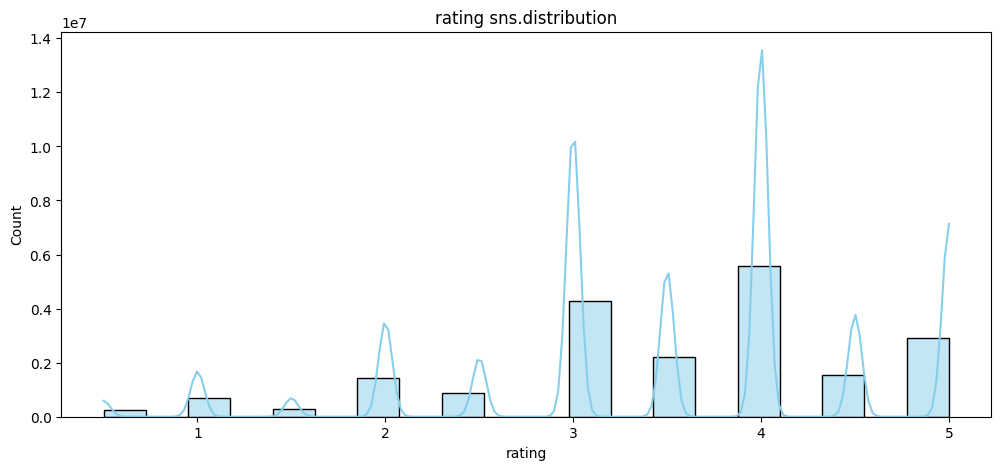

In [26]:
# step 5 Univariate Analysis
#start with 'movieId' and 'userid'
plt.figure(figsize=(12, 5))
sns.histplot(df['rating'].dropna(), kde=True, bins= 20, color='skyblue')
plt.title("rating sns.distribution")
plt.xlabel("rating")
plt.show()